In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits  # <-- CHANGED
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [2]:
from sklearn.model_selection import train_test_split
# Set a consistent style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
from sklearn.datasets import load_digits
digits = load_digits()
X = digits.data
y = digits.target
mask = (y == 0) | (y == 1)
X_binary = X[mask]
y_binary = y[mask]

In [4]:
target_names_binary = ["Digit 0", "Digit 1"]

In [5]:
print("--- Dataset Information (Binary 0 vs 1) ---")
print(f"Features: {X_binary.shape[1]} (8x8 pixels)")
print(f"Samples: {X_binary.shape[0]}")
print(f"Class distribution: {np.bincount(y_binary)}")

--- Dataset Information (Binary 0 vs 1) ---
Features: 64 (8x8 pixels)
Samples: 360
Class distribution: [178 182]


In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_binary)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42
)

In [8]:
class MyAdaBoost:
    
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.alphas_ = []      # To store the 'say' (alpha) of each classifier
        self.clfs_ = []        # To store each weak classifier (stump)
        self.random_state = 42 # For reproducible weak learners
        
    def fit(self, X, y):
        """
        Trains the AdaBoost model on the training data (X, y).
        
        Note: This implementation assumes binary classification with labels {0, 1}.
        It internally converts them to {-1, 1} for the algorithm's math.
        """
        n_samples = X.shape[0]
        
        # 1. Convert labels from {0, 1} to {-1, 1}
        y_boost = np.where(y == 0, -1, 1)
        
        # 2. Initialize sample weights: w_i = 1/N for all i
        w = np.full(n_samples, (1 / n_samples))
        
        # Clear any previously fitted models
        self.clfs_ = []
        self.alphas_ = []
        
        # 3. Loop for M estimators (n_estimators)
        for i in range(self.n_estimators):
            # 4. Create and fit a weak learner (Decision Stump)
            clf = DecisionTreeClassifier(max_depth=1, random_state=self.random_state + i)
            
            # The learner is fit using the *original y labels* but with *sample weights (w)*
            clf.fit(X, y, sample_weight=w)
            
            # 5. Get predictions from the weak learner (h_m(x))
            y_pred_raw = clf.predict(X)
            y_pred = np.where(y_pred_raw == 0, -1, 1)
            
            # 6. Calculate the weighted error (epsilon) of the learner
            misclassified_mask = (y_pred != y_boost)
            error = np.sum(w[misclassified_mask])
            
            # Avoid division by zero if error is 0
            if error == 0:
                error = 1e-10 
            
            # 7. Calculate the classifier's 'say' (alpha)
            alpha = 0.5 * np.log((1.0 - error) / error)
            
            # 8. Update sample weights
            w *= np.exp(-alpha * y_boost * y_pred)
            
            # 9. Normalize weights (so they sum to 1)
            w /= np.sum(w)
            
            # 10. Store the classifier and its alpha
            self.clfs_.append(clf)
            self.alphas_.append(alpha)

            
    def predict(self, X):
        """
        Predicts class labels for samples in X.
        
        Returns:
        --------
        y_pred : array-like
            Predicted class labels as {0, 1}.
        """
        
        # Get predictions from all weak learners in {-1, 1} format
        clf_preds = []
        for clf in self.clfs_:
            y_pred_raw = clf.predict(X)
            y_pred = np.where(y_pred_raw == 0, -1, 1)
            clf_preds.append(y_pred)
            
        # Calculate the weighted sum: H(x) = sign( sum(alpha_m * h_m(x)) )
        pred_sum = np.dot(self.alphas_, clf_preds)
        
        # The sign of the sum gives the final prediction in {-1, 1}
        y_pred_boost = np.sign(pred_sum)
        
        # Convert back from {-1, 1} to {0, 1} for the final output
        y_pred_final = np.where(y_pred_boost == -1, 0, 1)
        
        return y_pred_final

In [9]:
# 1. Initialize and train our model
# Let's use 50 estimators
adaboost_scratch = MyAdaBoost(n_estimators=50)
adaboost_scratch.fit(X_train, y_train)

# 2. Get predictions on the test set
y_pred_scratch = adaboost_scratch.predict(X_test)

# 3. Evaluate the performance
print("--- AdaBoost (From Scratch) Results ---")
print(classification_report(y_test, y_pred_scratch, target_names=target_names_binary)) # <-- UPDATED
print(f"Accuracy: {accuracy_score(y_test, y_pred_scratch):.4f}")

# Store metrics for later comparison
metrics_scratch = {
    "Accuracy": accuracy_score(y_test, y_pred_scratch),
    "Precision": precision_score(y_test, y_pred_scratch),
    "Recall": recall_score(y_test, y_pred_scratch),
    "F1-Score": f1_score(y_test, y_pred_scratch)
}

--- AdaBoost (From Scratch) Results ---
              precision    recall  f1-score   support

     Digit 0       1.00      1.00      1.00        35
     Digit 1       1.00      1.00      1.00        37

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72

Accuracy: 1.0000


In [10]:
# 1. Initialize and train the baseline model (a single, deep Decision Tree)
baseline_tree = DecisionTreeClassifier(random_state=42)
baseline_tree.fit(X_train, y_train)

# 2. Get predictions on the test set
y_pred_tree = baseline_tree.predict(X_test)

# 3. Evaluate the performance
print("--- Baseline Decision Tree Results ---")
print(classification_report(y_test, y_pred_tree, target_names=target_names_binary)) # <-- UPDATED
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")

# Store metrics for later comparison
metrics_tree = {
    "Accuracy": accuracy_score(y_test, y_pred_tree),
    "Precision": precision_score(y_test, y_pred_tree),
    "Recall": recall_score(y_test, y_pred_tree),
    "F1-Score": f1_score(y_test, y_pred_tree)
}

--- Baseline Decision Tree Results ---
              precision    recall  f1-score   support

     Digit 0       0.97      1.00      0.99        35
     Digit 1       1.00      0.97      0.99        37

    accuracy                           0.99        72
   macro avg       0.99      0.99      0.99        72
weighted avg       0.99      0.99      0.99        72

Accuracy: 0.9861


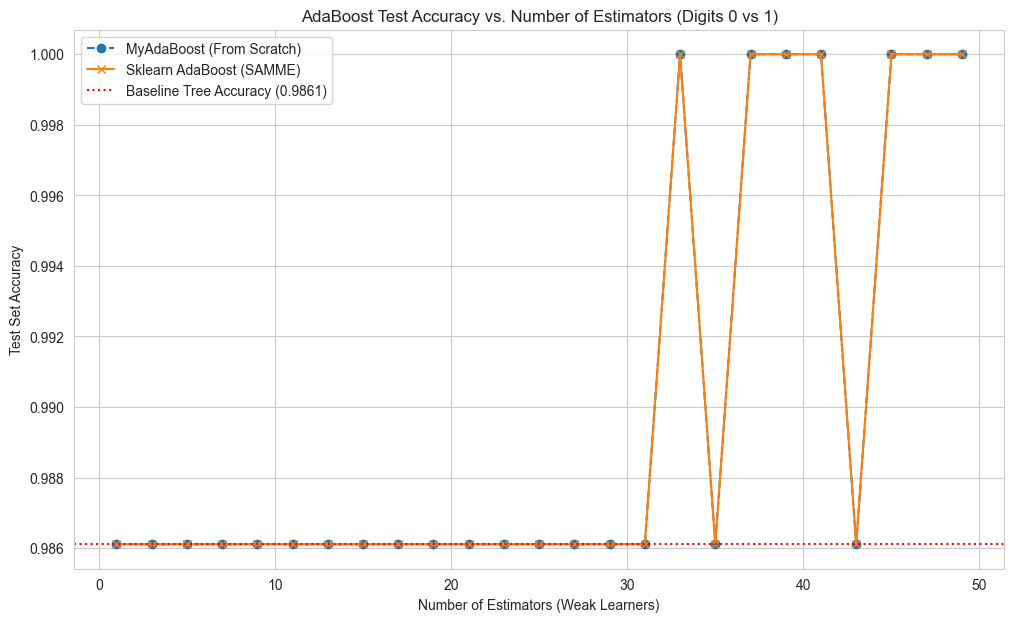

In [11]:
# This cell fulfills Task 5: Visualize performance curves

# 1. We will track the test accuracy as we add more estimators
n_estimators_range = range(1, 51, 2) # Test from 1 to 50 estimators
scratch_accuracies = []
sklearn_accuracies = []

# 2. Test our "From Scratch" model
for n in n_estimators_range:
    model_scratch = MyAdaBoost(n_estimators=n)
    model_scratch.fit(X_train, y_train)
    y_pred = model_scratch.predict(X_test)
    scratch_accuracies.append(accuracy_score(y_test, y_pred))

# 3. Test the sklearn model for comparison
from sklearn.ensemble import AdaBoostClassifier
stump = DecisionTreeClassifier(max_depth=1)
for n in n_estimators_range:
    model_sklearn = AdaBoostClassifier(
        estimator=stump,
        n_estimators=n,
        algorithm='SAMME',
        random_state=42
    )
    model_sklearn.fit(X_train, y_train)
    y_pred = model_sklearn.predict(X_test)
    sklearn_accuracies.append(accuracy_score(y_test, y_pred))

# 4. Plot the learning curves
plt.figure(figsize=(12, 7))
plt.plot(n_estimators_range, scratch_accuracies, label='MyAdaBoost (From Scratch)', marker='o', linestyle='--')
plt.plot(n_estimators_range, sklearn_accuracies, label='Sklearn AdaBoost (SAMME)', marker='x')
plt.axhline(y=metrics_tree["Accuracy"], color='r', linestyle=':', label=f'Baseline Tree Accuracy ({metrics_tree["Accuracy"]:.4f})')
plt.title('AdaBoost Test Accuracy vs. Number of Estimators (Digits 0 vs 1)')
plt.xlabel('Number of Estimators (Weak Learners)')
plt.ylabel('Test Set Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from sklearn.ensemble import AdaBoostClassifier

# 1. Initialize and train the sklearn model
# We use the same base estimator and n_estimators from Cell 4
stump = DecisionTreeClassifier(max_depth=1)
ada_sklearn = AdaBoostClassifier(
    estimator=stump,
    n_estimators=50, # Match n_estimators from Cell 4
    algorithm='SAMME', # Use 'SAMME' to match our discrete algorithm
    random_state=42
)
ada_sklearn.fit(X_train, y_train)

# 2. Get predictions
y_pred_sklearn = ada_sklearn.predict(X_test)

# 3. Evaluate
print("--- Scikit-learn AdaBoost Results (Validation) ---")
print(classification_report(y_test, y_pred_sklearn, target_names=target_names_binary)) # <-- UPDATED
print(f"Accuracy: {accuracy_score(y_test, y_pred_sklearn):.4f}")

# Store metrics
metrics_sklearn = {
    "Accuracy": accuracy_score(y_test, y_pred_sklearn),
    "Precision": precision_score(y_test, y_pred_sklearn),
    "Recall": recall_score(y_test, y_pred_sklearn),
    "F1-Score": f1_score(y_test, y_pred_sklearn)
}

--- Scikit-learn AdaBoost Results (Validation) ---
              precision    recall  f1-score   support

     Digit 0       1.00      1.00      1.00        35
     Digit 1       1.00      1.00      1.00        37

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72

Accuracy: 1.0000


In [13]:
# Create a dictionary of our results (using 50 estimators for AdaBoost models)
data = {
    "AdaBoost (From Scratch)": metrics_scratch,
    "Baseline Decision Tree": metrics_tree,
    "AdaBoost (Sklearn)": metrics_sklearn
}

# Convert to DataFrame
results_df = pd.DataFrame(data).T

# Format for better readability
results_df = results_df.applymap(lambda x: f"{x:.4f}")

print("--- 📊 Model Performance Comparison (Digits 0 vs 1) ---")
print(results_df)

--- 📊 Model Performance Comparison (Digits 0 vs 1) ---
                        Accuracy Precision  Recall F1-Score
AdaBoost (From Scratch)   1.0000    1.0000  1.0000   1.0000
Baseline Decision Tree    0.9861    1.0000  0.9730   0.9863
AdaBoost (Sklearn)        1.0000    1.0000  1.0000   1.0000


C:\Users\Kathan Vyas\AppData\Local\Temp\ipykernel_5032\922179250.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results_df = results_df.applymap(lambda x: f"{x:.4f}")
